# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Load Data

In [2]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

# Dataset Overview

## Head

In [3]:
train_df.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


## Info

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   

## Describe

In [5]:
train_df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,140700.000000,140700.000000,27897.000000,112782.000000,27898.000000,27897.000000,112790.000000,140700.000000,140696.000000,140700.000000
mean,70349.500000,40.388621,3.142273,2.998998,7.658636,2.944940,2.974404,6.252679,2.988983,0.181713
std,40616.735775,12.384099,1.380457,1.405771,1.464466,1.360197,1.416078,3.853615,1.413633,0.385609
min,0.000000,18.000000,1.000000,1.000000,5.030000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,35174.750000,29.000000,2.000000,2.000000,6.290000,2.000000,2.000000,3.000000,2.000000,0.000000
50%,70349.500000,42.000000,3.000000,3.000000,7.770000,3.000000,3.000000,6.000000,3.000000,0.000000
75%,105524.250000,51.000000,4.000000,4.000000,8.920000,4.000000,4.000000,10.000000,4.000000,0.000000
max,140699.000000,60.000000,5.000000,5.000000,10.000000,5.000000,5.000000,12.000000,5.000000,1.000000


## Missing & Duplicate Value

In [6]:
total = train_df.isnull().sum().sort_values(ascending=False)
percent = (train_df.isnull().sum()/train_df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Missing Percent'])

In [7]:
missing_data['Missing Percent'] = missing_data['Missing Percent'].apply(lambda x: x*100)
missing_data.loc[missing_data['Missing Percent'] > 10][:10]

,Total,Missing Percent
Study Satisfaction,112803,80.172708
Academic Pressure,112803,80.172708
CGPA,112802,80.171997
Profession,36630,26.034115
Work Pressure,27918,19.842217
Job Satisfaction,27910,19.836532


## Imbalance Data

In [8]:
count_class = train_df['Depression'].value_counts()
count_class

Depression
0    115133
1     25567
Name: count, dtype: int64

# EDA

## Split Num and Cat Variable

In [9]:
numerical_vars = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction',
                  'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression']

categorical_vars = ['Gender', 'Working Professional or Student', 'Sleep Duration', 'Dietary Habits', 
                    'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

In [10]:
train_df = train_df[numerical_vars+categorical_vars]
train_df.columns

Index(['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
       'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours',
       'Financial Stress', 'Depression', 'Gender',
       'Working Professional or Student', 'Sleep Duration', 'Dietary Habits',
       'Have you ever had suicidal thoughts ?',
       'Family History of Mental Illness'],
      dtype='object')

## Data Profiling

In [11]:
# from ydata_profiling import ProfileReport

# profile = ProfileReport(df, title="Data Understanding")
# profile.to_file("data_understanding_report.html")

# Data Preprocessing

## Filtering Categorical

In [12]:
def identify_cat_above30(series):
    counts = series.value_counts()
    return list(counts[counts>=30].index)

In [13]:
levels_to_keep = train_df[categorical_vars].apply(identify_cat_above30, axis=0)
levels_to_keep

Gender                                                                      [Male, Female]
Working Professional or Student                            [Working Professional, Student]
Sleep Duration                           [Less than 5 hours, 7-8 hours, More than 8 hou...
Dietary Habits                                              [Moderate, Unhealthy, Healthy]
Have you ever had suicidal thoughts ?                                            [No, Yes]
Family History of Mental Illness                                                 [No, Yes]
dtype: object

## Handling Missing Value

In [14]:
columns_to_drop = ['Study Satisfaction',
                   'Academic Pressure',
                   'CGPA',
                   'Work Pressure',
                   'Job Satisfaction']

In [15]:
train_df = train_df.drop(columns=columns_to_drop)

In [16]:
total = train_df.isnull().sum().sort_values(ascending=False)
percent = (train_df.isnull().sum()/train_df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Missing Percent'])

missing_data

,Total,Missing Percent
Financial Stress,4,0.000028
Dietary Habits,4,0.000028
Age,0,0.000000
Work/Study Hours,0,0.000000
Depression,0,0.000000
Gender,0,0.000000
Working Professional or Student,0,0.000000
Sleep Duration,0,0.000000
Have you ever had suicidal thoughts ?,0,0.000000
Family History of Mental Illness,0,0.000000


In [17]:
imputer = SimpleImputer(strategy='most_frequent')

train_df[['Financial Stress', 'Dietary Habits']] = imputer.fit_transform(train_df[['Financial Stress', 'Dietary Habits']])

In [18]:
total = train_df.isnull().sum().sort_values(ascending=False)
percent = (train_df.isnull().sum()/train_df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Missing Percent'])

missing_data

,Total,Missing Percent
Age,0,0.0
Work/Study Hours,0,0.0
Financial Stress,0,0.0
Depression,0,0.0
Gender,0,0.0
Working Professional or Student,0,0.0
Sleep Duration,0,0.0
Dietary Habits,0,0.0
Have you ever had suicidal thoughts ?,0,0.0
Family History of Mental Illness,0,0.0


## Split Data

In [19]:
numerical_vars_clean = ['Age', 'Work/Study Hours', 'Financial Stress', 'Depression']

categorical_vars_clean = ['Gender', 'Working Professional or Student', 'Sleep Duration', 'Dietary Habits', 
                            'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

train_df = train_df[numerical_vars_clean+categorical_vars_clean]

In [20]:
X = train_df.drop(columns='Depression')
y = train_df['Depression']

## Label Encoder

In [21]:
for col in categorical_vars_clean:
    le = LabelEncoder()
    X.loc[:, col] = le.fit_transform(X[col])

## Scaler

In [22]:
scaler = StandardScaler()

In [23]:
X = scaler.fit_transform(X)

## SMOTE

In [24]:
smote = SMOTE(sampling_strategy='minority')
X, y = smote.fit_resample(X, y)

In [25]:
count_class = y.value_counts()
count_class

Depression
0    115133
1    115133
Name: count, dtype: int64

# Modelling

In [26]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

In [27]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15/(1-0.15), random_state=42
)

In [28]:
print(f"Training data shape: {X_train.shape}, Validation data shape: {X_val.shape}, Test data shape: {X_test.shape}")

Training data shape: (161186, 9), Validation data shape: (34540, 9), Test data shape: (34540, 9)


## Model Definition & Cross Validation

### RF

In [29]:
rf_model = RandomForestClassifier(random_state=42)

In [30]:
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)

In [31]:
print("Random Forest - Cross Validation Scores: ", rf_cv_scores)
print("Mean CV score: ", rf_cv_scores.mean())

Random Forest - Cross Validation Scores:  [0.93886097 0.94044111 0.9393554  0.94140274 0.93848683]
Mean CV score:  0.9397094093062535


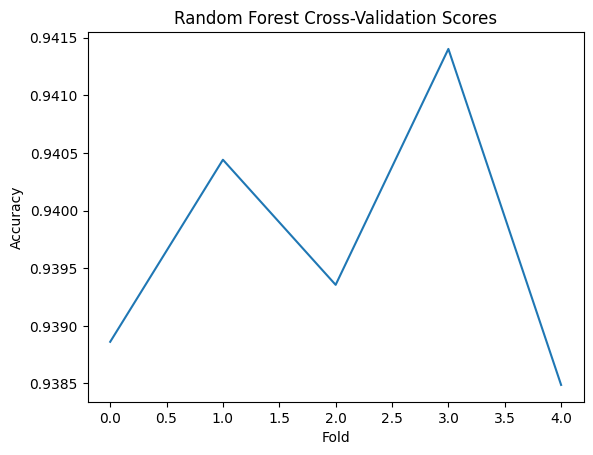

In [32]:
plt.plot(rf_cv_scores)
plt.title('Random Forest Cross-Validation Scores')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.show()

### XGBoost

In [33]:
xgb_model = XGBClassifier(random_state=42)

In [34]:
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5)

In [35]:
print("XGBoost - Cross Validation Scores: ", xgb_cv_scores)
print("Mean CV score: ", xgb_cv_scores.mean())

XGBoost - Cross Validation Scores:  [0.94441343 0.94593169 0.94490802 0.94850637 0.94667618]
Mean CV score:  0.946087139538883


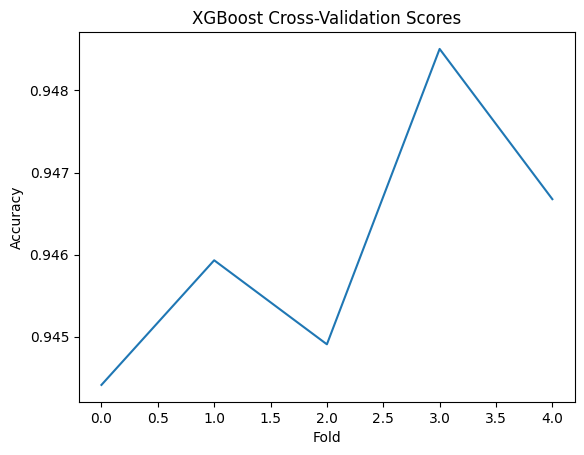

In [36]:
plt.plot(xgb_cv_scores)
plt.title('XGBoost Cross-Validation Scores')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.show()

### Neural Network - MLP

In [37]:
nn_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

In [38]:
nn_cv_scores = cross_val_score(nn_model, X_train, y_train, cv=5)

In [39]:
print("Neural Network (MLP) - Cross Validation Scores: ", nn_cv_scores)
print("Mean CV score: ", nn_cv_scores.mean())

Neural Network (MLP) - Cross Validation Scores:  [0.90846206 0.91063064 0.90818004 0.9122437  0.90759066]
Mean CV score:  0.9094214197222856


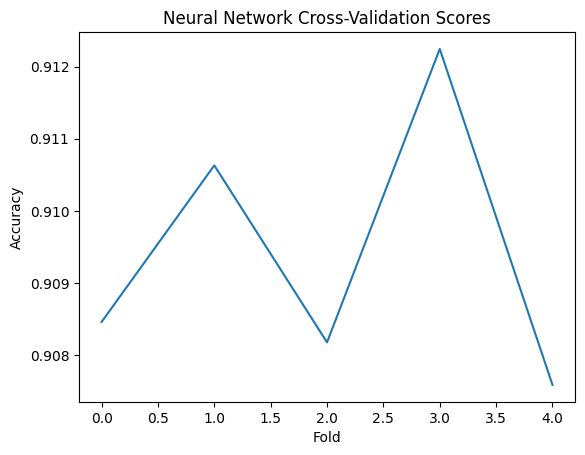

In [40]:
plt.plot(nn_cv_scores)
plt.title('Neural Network Cross-Validation Scores')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.show()

## Model Evaluation

### RF Evaluation

In [41]:
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)

In [42]:
print("Classification Report for Random Forest:")
print(classification_report(y_test, rf_y_pred))

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94     17137
           1       0.94      0.95      0.94     17403

    accuracy                           0.94     34540
   macro avg       0.94      0.94      0.94     34540
weighted avg       0.94      0.94      0.94     34540



### XGBoost Evaluation

In [43]:
xgb_model.fit(X_train, y_train)
xgb_y_pred = xgb_model.predict(X_test)

In [44]:
print("Classification Report for XGBoost:")
print(classification_report(y_test, xgb_y_pred))

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95     17137
           1       0.94      0.95      0.95     17403

    accuracy                           0.95     34540
   macro avg       0.95      0.95      0.95     34540
weighted avg       0.95      0.95      0.95     34540



### Neural Network - MLP Evaluation

In [45]:
nn_model.fit(X_train, y_train)
nn_y_pred = nn_model.predict(X_test)

In [46]:
print("Classification Report for Neural Network (MLP):")
print(classification_report(y_test, nn_y_pred))

Classification Report for Neural Network (MLP):
              precision    recall  f1-score   support

           0       0.92      0.90      0.91     17137
           1       0.90      0.92      0.91     17403

    accuracy                           0.91     34540
   macro avg       0.91      0.91      0.91     34540
weighted avg       0.91      0.91      0.91     34540



## Submission

### Data Test Preprocessing

In [47]:
test_df.columns

Index(['id', 'Name', 'Gender', 'Age', 'City',
       'Working Professional or Student', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness'],
      dtype='object')

In [48]:
columns_to_drop = ['Name', 'City', 'Profession', 'Academic Pressure',
                   'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
                   'Degree']

test_df = test_df.drop(columns=columns_to_drop)
test_df.columns

Index(['id', 'Gender', 'Age', 'Working Professional or Student',
       'Sleep Duration', 'Dietary Habits',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness'],
      dtype='object')

In [49]:
numerical_vars_test = ['Age', 'Work/Study Hours', 'Financial Stress']

categorical_vars_test = ['Gender', 'Working Professional or Student', 'Sleep Duration', 'Dietary Habits', 
                            'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

test_df_predict = test_df[numerical_vars_test+categorical_vars_test]

In [50]:
for col in categorical_vars_test:
    test_df_predict.loc[:, col] = le.fit_transform(test_df_predict[col])

In [51]:
test_df_predict = scaler.fit_transform(test_df_predict)

### Prediction RF

In [52]:
y_pred_rf = rf_model.predict(test_df_predict)

In [53]:
test_df.loc[:, 'Depression'] = y_pred_rf

In [54]:
submission_rf = test_df[['id', 'Depression']]

In [55]:
submission_rf.to_csv('../data/submission-rf-revisi.csv', index=False)

### Prediction XGBoost

In [56]:
y_pred_xgb = xgb_model.predict(test_df_predict)

In [57]:
test_df.loc[:, 'Depression'] = y_pred_xgb

In [58]:
submission_xgb = test_df[['id', 'Depression']]

In [59]:
submission_xgb.to_csv('../data/submission-xgb-revisi.csv', index=False)

### Prediction Neural Network - MLP

In [60]:
y_pred_nn = nn_model.predict(test_df_predict)

In [61]:
test_df.loc[:, 'Depression'] = y_pred_nn

In [62]:
submission_nn = test_df[['id', 'Depression']]

In [63]:
submission_nn.to_csv('../data/submission-nn-revisi.csv', index=False)

## Make Pickle 

In [64]:
import pickle

# Simpan encoder ke dalam file pickle
with open('scale.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("scaler berhasil disimpan ke scale.pkl")

scaler berhasil disimpan ke scale.pkl


In [65]:
import pickle

# Simpan scaler ke dalam file pickle
with open('encode.pkl', 'wb') as file:
    pickle.dump(le, file)

print("label encoder berhasil disimpan ke encode.pkl")

label encoder berhasil disimpan ke encode.pkl


In [66]:
import pickle

# Simpan model XGBoost ke dalam file pickle
with open('xgboost.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)

print("Model XGBoost berhasil disimpan ke xgboost.pkl")

Model XGBoost berhasil disimpan ke xgboost.pkl


In [69]:
import pickle

# Simpan model NN ke dalam file pickle
with open('nn.pkl', 'wb') as file:
    pickle.dump(nn_model, file)

print("Model NN berhasil disimpan ke nn.pkl")

Model NN berhasil disimpan ke nn.pkl
